The problem centers on a potential resource collision between two independent computing jobs that start at random times within the same 5-hour window. Since each job lasts one hour, they will fail if their start times are within 60 minutes of each other.

The code solves this by calculating the expected annual cost of these failures. It uses two methods to find the 36% probability of collision:

- Mathematical Logic: It calculates the "safe" area where no overlap occurs and subtracts it from the total possible outcomes.

- Monte Carlo Simulation: It simulates millions of random start-time scenarios to verify that the theoretical 36% failure rate holds true in practice.

Ultimately, the code converts this probability into a concrete financial figure ($131,400) to show the business impact of the scheduling conflict.

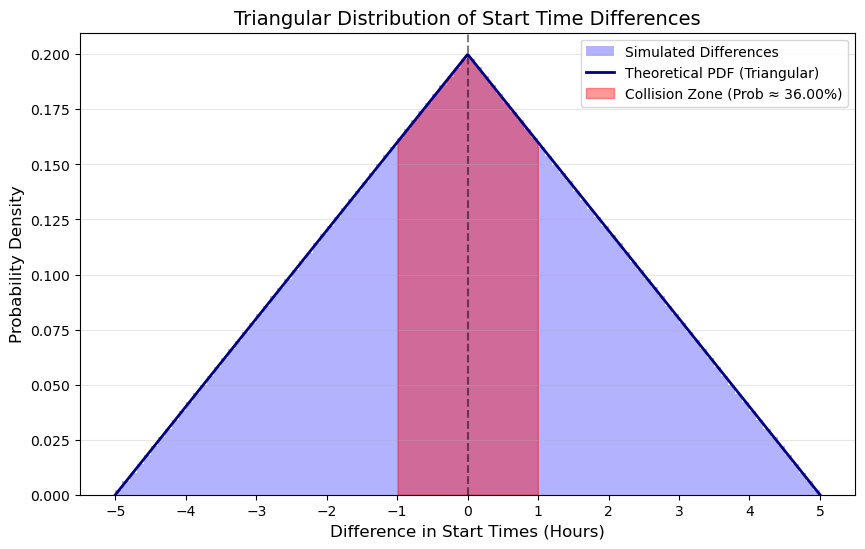

--- Results ---
Probability of overlap: 0.3600
Total Annual Cost: $131,390.15


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def solve_with_distribution_plot():
    window = 5
    duration = 1
    cost_per_event = 1000
    days_in_year = 365
    iterations = 100_000_000


    job1_starts = np.random.uniform(0, window, iterations)
    job2_starts = np.random.uniform(0, window, iterations)
    
    differences = job1_starts - job2_starts
    
    collisions = np.abs(differences) < duration
    prob_failure = np.mean(collisions)
    annual_cost = prob_failure * cost_per_event * days_in_year

    plt.figure(figsize=(10, 6))
    
    plt.hist(differences, bins=100, density=True, alpha=0.3, color='blue', label='Simulated Differences')
    
    z = np.linspace(-window, window, 1000)
    pdf = (window - np.abs(z)) / (window**2)
    plt.plot(z, pdf, color='navy', lw=2, label='Theoretical PDF (Triangular)')
    
    plt.fill_between(z, 0, pdf, where=(np.abs(z) < duration), 
                     color='red', alpha=0.4, label=f'Collision Zone (Prob ≈ {prob_failure:.2%})')

    plt.title('Triangular Distribution of Start Time Differences', fontsize=14)
    plt.xlabel('Difference in Start Times (Hours)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.xticks(range(-window, window + 1))
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

    print(f"--- Results ---")
    print(f"Probability of overlap: {prob_failure:.4f}")
    print(f"Total Annual Cost: ${annual_cost:,.2f}")

if __name__ == "__main__":
    solve_with_distribution_plot()